# 1. Exploratory Data Analysis — What Does the Data Tell Us?

Before building any prediction model, we first need to understand the data. This notebook answers:
- **How big is our dataset, and is the data clean?**
- **How many bookings actually get cancelled?**
- **Which booking characteristics seem connected to cancellations?**
- **Are there any data traps we need to avoid?**

**Prerequisites**: Run `make train` to generate reports referenced in sections 1.2 and 1.4.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import (
    BOOKING_TIME_FEATURES,
    LEAKAGE_COLS,
    TARGET_COL,
    TRAIN_RATIO,
    VAL_RATIO,
)
from src.data.load import load_raw_data
from src.eval.notebook_utils import (
    load_main_context,
    plot_monthly_trend,
    project_root,
    save_thesis_figure,
    setup_plotting,
)
from src.features.build import add_arrival_date, split_time_aware
from src.utils.validate_data import clean_raw, validate_raw

cfg = setup_plotting()
FIG_DIR = cfg["fig_dir"]
ROOT = project_root()

print(f"Project root: {ROOT}")

Project root: D:\PythonProject1


## 1.1 How Big Is Our Dataset?

We start by loading the raw hotel bookings data and running automatic quality checks (fixing missing values, removing invalid rows).

In [2]:
df_raw = load_raw_data()
print(f"Raw shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Raw shape: 119,390 rows x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [3]:
df, clean_actions = clean_raw(df_raw)
validation = validate_raw(df)
print(f"After cleaning: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Validation passed: {validation.passed}")
if not validation.passed:
    for msg in validation.messages:
        print(f"  - {msg}")

After cleaning: 119,209 rows x 40 columns
Validation passed: True


## 1.2 Is the Data Clean?

These pre-computed reports (generated during training) show any data quality issues and how much information is missing per column.

In [4]:
quality_path = ROOT / "reports" / "data_quality_checks.csv"
if quality_path.exists():
    quality = pd.read_csv(quality_path)
    display(quality.style.format({"pct": "{:.2f}%"}).set_caption("Data Quality Checks"))
else:
    print("Data quality report not found. Run `make train` first.")

,check,count,pct
0,duplicate_rows,31994,26.80%
1,zero_guest_bookings,180,0.15%
2,zero_night_stays,715,0.60%
3,adr_zero_or_negative,1960,1.64%


In [5]:
missing_path = ROOT / "reports" / "missingness_report.csv"
if missing_path.exists():
    missing = pd.read_csv(missing_path)
    display(missing.style.format({"missing_pct": "{:.2f}%"}).set_caption("Missingness Report"))
else:
    print("Missingness report not found. Run `make train` first.")

,column,missing_count,missing_pct
0,company,112593,94.31%
1,agent,16340,13.69%
2,country,488,0.41%
3,children,4,0.00%


In [6]:
df.dtypes.value_counts().to_frame("count").rename_axis("dtype").reset_index()

,dtype,count
0,int64,21
1,object,12
2,float64,7


## 1.3 How Many Bookings Get Cancelled?

The chart below shows the split between kept and cancelled bookings. The target variable `is_canceled` is binary: 1 = cancelled, 0 = kept.

**Key Takeaway — Cancellation Rate**: About **37% of bookings are cancelled** — roughly one in three. This is important because a naive model that always predicts "not cancelled" would still be 63% accurate, which sounds good but is actually useless. That's why we use a smarter metric called **PR-AUC** (Precision-Recall Area Under Curve) that specifically measures how well we detect the cancellations.

## 1.4 Does the Cancellation Rate Change Over Time?

The chart below shows the monthly cancellation rate (blue line with grey confidence band) and booking volume (orange bars). Vertical dashed lines mark where we split the data for training vs. testing.

This uses the pre-built `plot_monthly_trend()` from `notebook_utils`.

**Key Takeaway — Time Trends**: The cancellation rate isn't flat — it trends upward in mid-2016 to early 2017. This means we can't just randomly shuffle the data for testing; we must split it **chronologically** (older data for training, newer data for testing) so the model is always evaluated on "future" bookings it hasn't seen. The vertical dashed lines show exactly where these splits occur.

## 1.5 What Patterns Do We See in Booking Numbers?

The histograms below show how key numerical features are distributed, split by cancellation status (blue = kept, red = cancelled). Where the red and blue shapes look very different, that feature is likely useful for prediction.

**Key Takeaway — Numerical Features**: 
- **Lead time** is the biggest differentiator: cancelled bookings are typically booked much further in advance (~130 days vs. ~45 days). People who plan far ahead are more likely to change their minds.
- **Room rate (ADR)**: Higher-priced bookings cancel slightly more often, suggesting price sensitivity.
- **Special requests**: Guests who make zero special requests cancel more often — they're less committed to the specific stay.
- **Previous cancellations**: Guests who cancelled before are much more likely to cancel again — past behaviour predicts future behaviour.

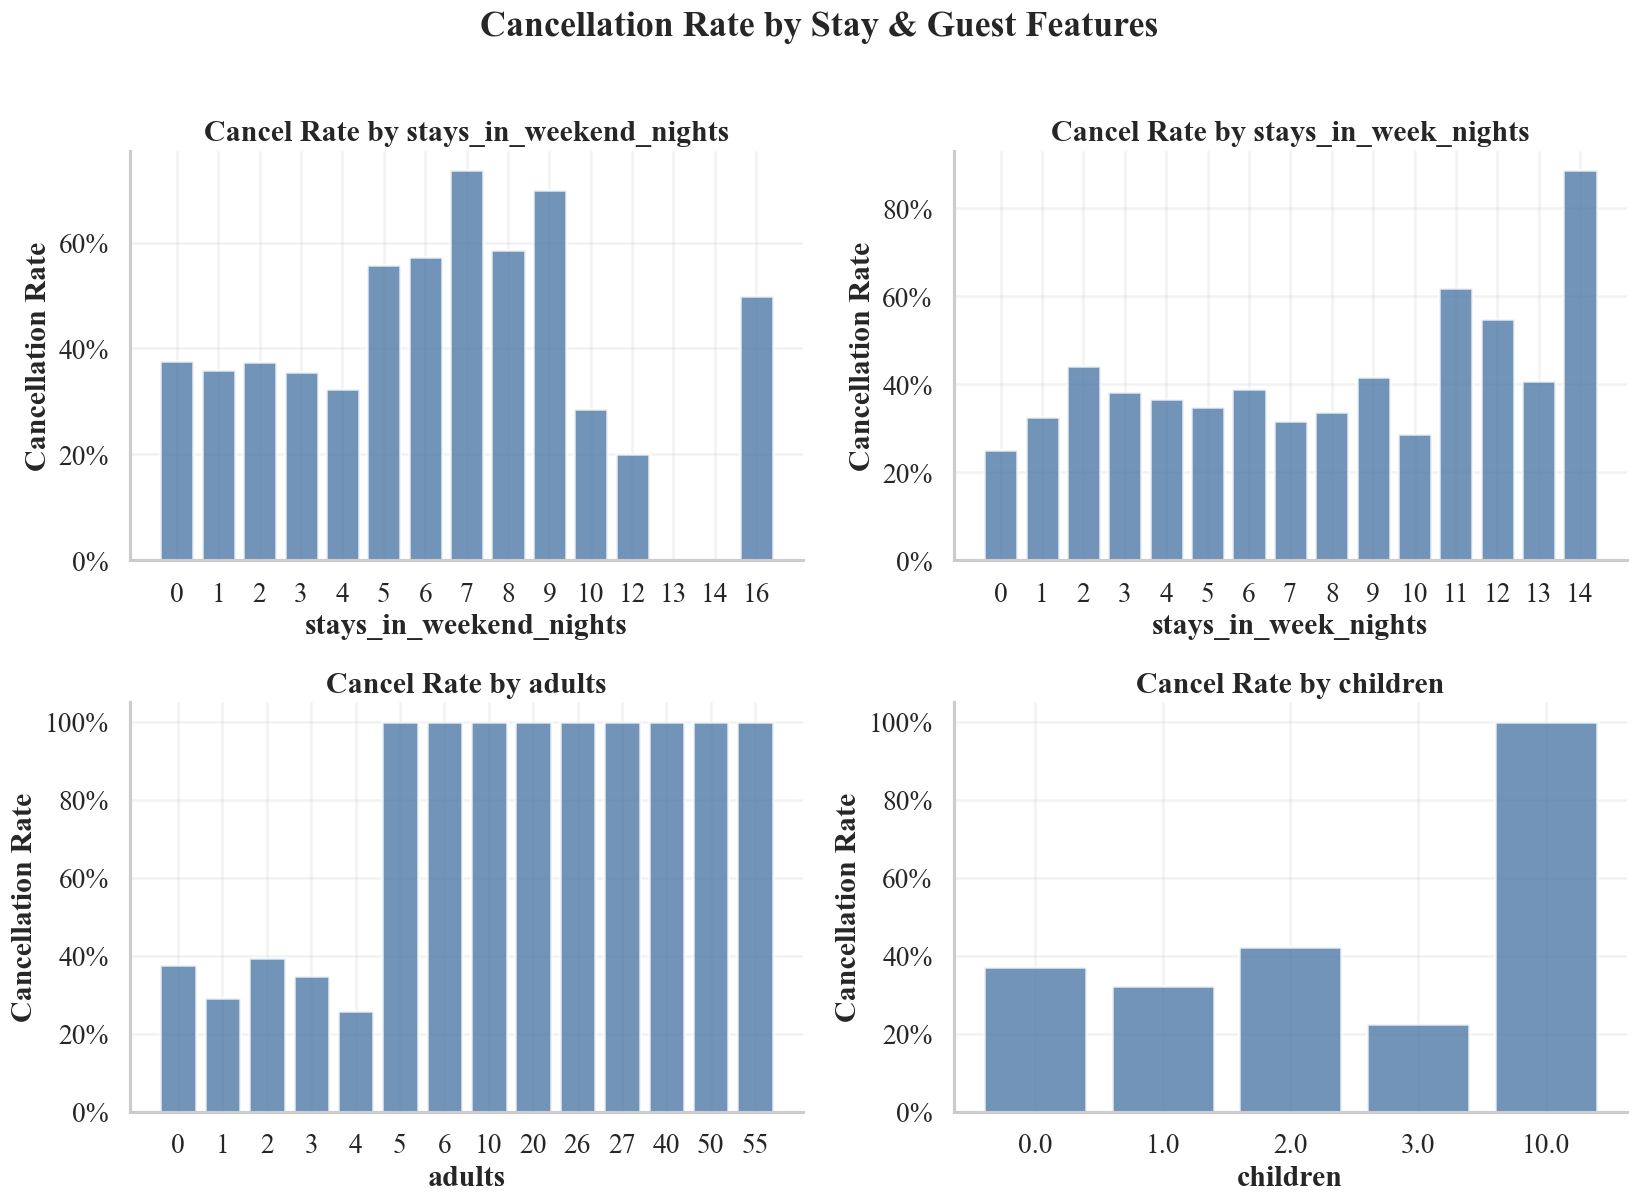

In [7]:
stay_features = ["stays_in_weekend_nights", "stays_in_week_nights", "adults", "children"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), stay_features):
    cancel_rate = df.groupby(col)[TARGET_COL].mean()
    counts = df[col].value_counts().sort_index()
    top_values = counts.head(15).index
    cancel_rate = cancel_rate.loc[cancel_rate.index.isin(top_values)]
    ax.bar(cancel_rate.index.astype(str), cancel_rate.values, color="#4e79a7", alpha=0.8)
    ax.set_title(f"Cancel Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Cancellation Rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

fig.suptitle("Cancellation Rate by Stay & Guest Features", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

**Key Takeaway — Stay & Guest Features**: Weekend and weeknight stays show relatively flat cancellation rates, meaning the length of stay alone isn't a strong predictor. The number of adults and children matters more at extremes — bookings with unusual guest counts (e.g., 0 children vs. 3+) show different patterns.

## 1.6 Which Booking Categories Have the Highest Cancellation Rates?

The horizontal bar charts below show cancellation rates broken down by hotel type, market segment, deposit type, and customer type. Longer bars = higher cancellation rates. The numbers in parentheses show how many bookings fall into each category.

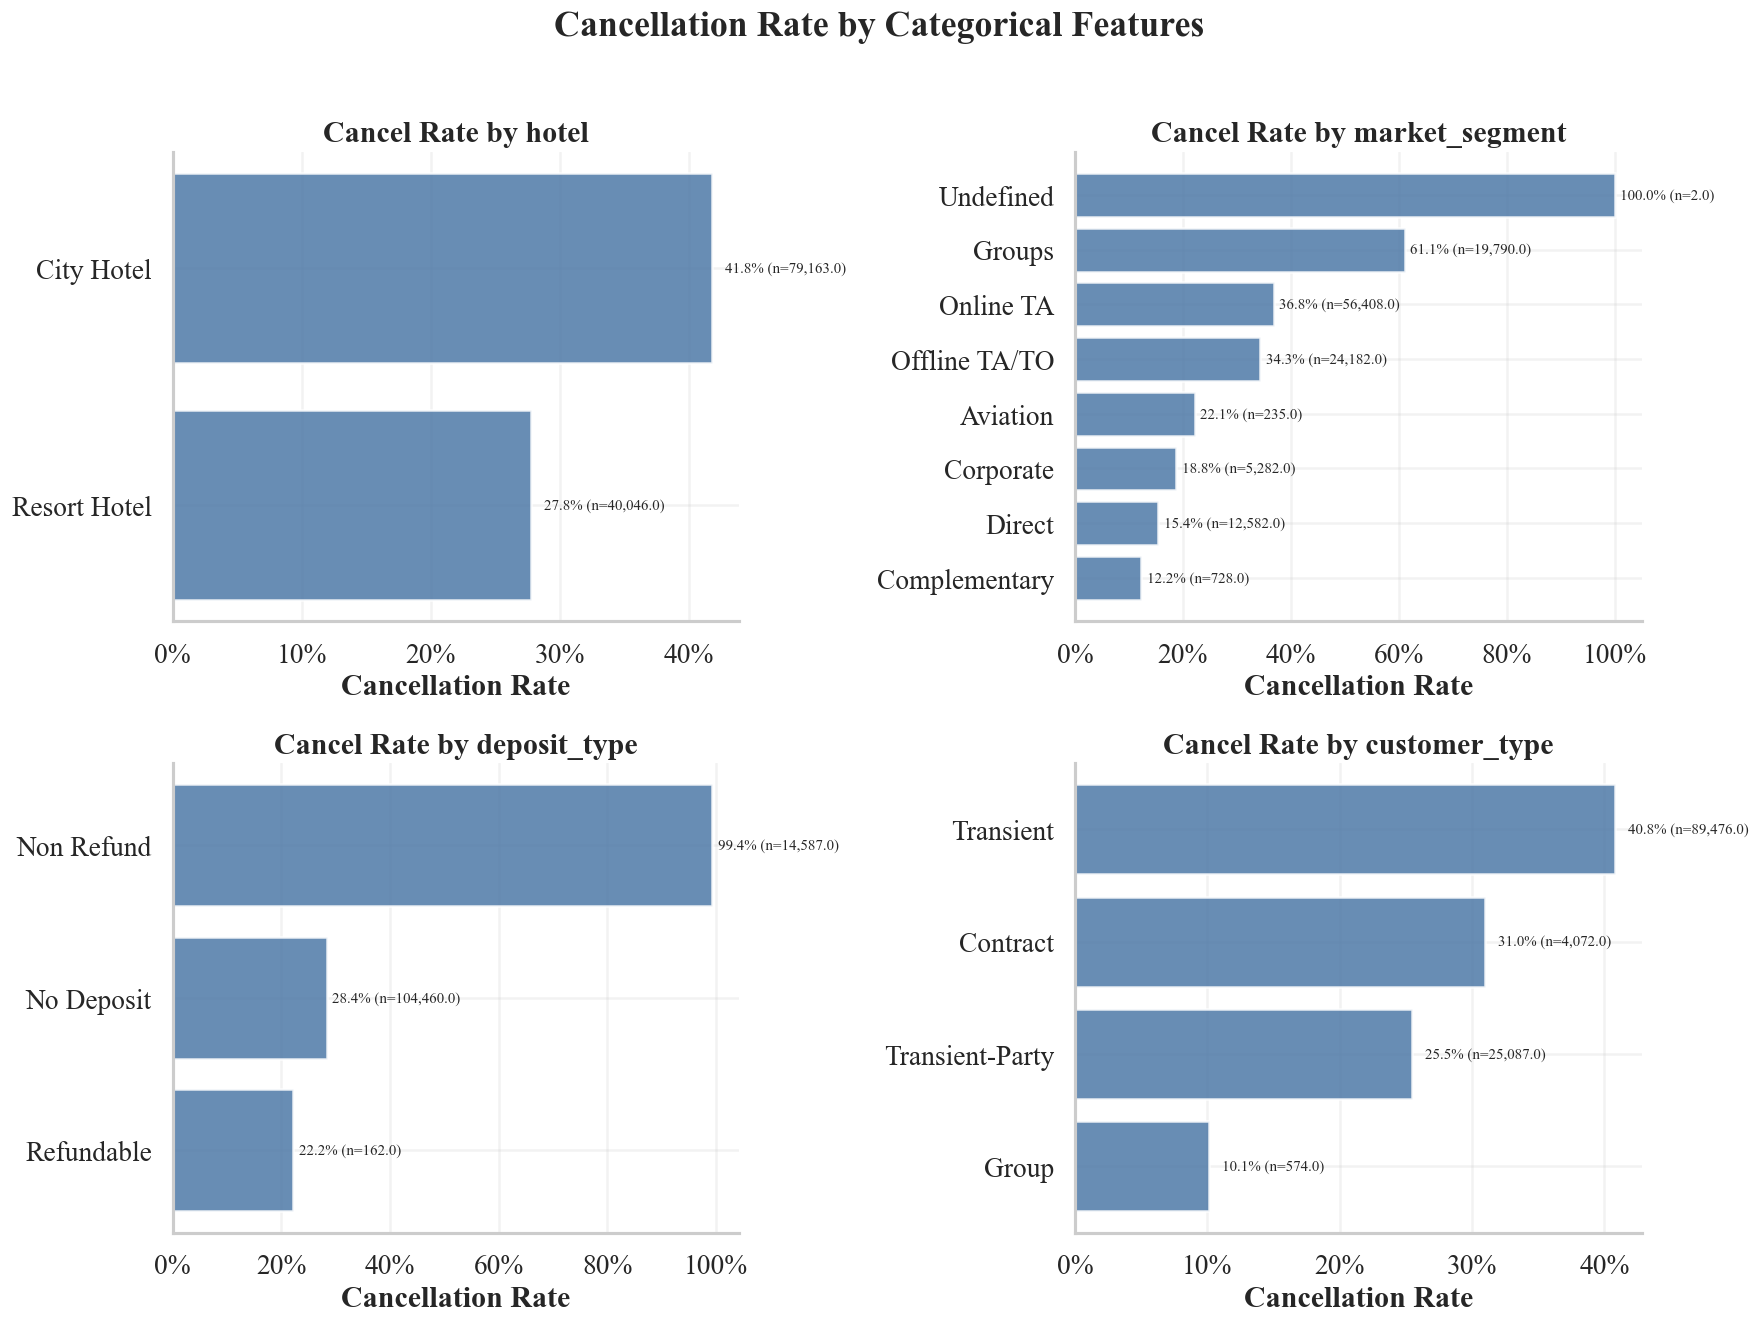

In [8]:
cat_features = ["hotel", "market_segment", "deposit_type", "customer_type"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for ax, col in zip(axes.ravel(), cat_features):
    summary = (
        df.groupby(col)[TARGET_COL]
        .agg(["mean", "count"])
        .rename(columns={"mean": "cancel_rate", "count": "n"})
        .sort_values("cancel_rate", ascending=True)
    )
    bars = ax.barh(summary.index.astype(str), summary["cancel_rate"], color="#4e79a7", alpha=0.85)
    for bar, (_, row) in zip(bars, summary.iterrows()):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{row['cancel_rate']:.1%} (n={row['n']:,})",
            va="center",
            fontsize=9,
        )
    ax.set_title(f"Cancel Rate by {col}")
    ax.set_xlabel("Cancellation Rate")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

fig.suptitle("Cancellation Rate by Categorical Features", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

**Key Takeaway — Categorical Features**:
- **City hotels** cancel more than resort hotels — city travellers may have more flexible plans.
- **Online Travel Agencies (OTAs)** and **Groups** have the highest cancellation rates among booking channels.
- **Transient** (individual, non-contract) customers cancel most often.
- **Non-Refundable deposits** show ~99% cancellation, but this is a **data recording convention**, not a real prediction signal. When a non-refundable booking is cancelled, the hotel keeps the money but still records the room as released. This is why we carefully exclude post-booking columns from the model.

## 1.7 Which Factors Are Most Connected to Cancellations?

The bar chart below ranks the top 10 numeric features by how strongly they correlate with cancellations. Red bars = positive correlation (higher value → more cancellations), blue bars = negative correlation (higher value → fewer cancellations).

We also list the **leakage columns** — data that would not be available at booking time and must be excluded from the model.

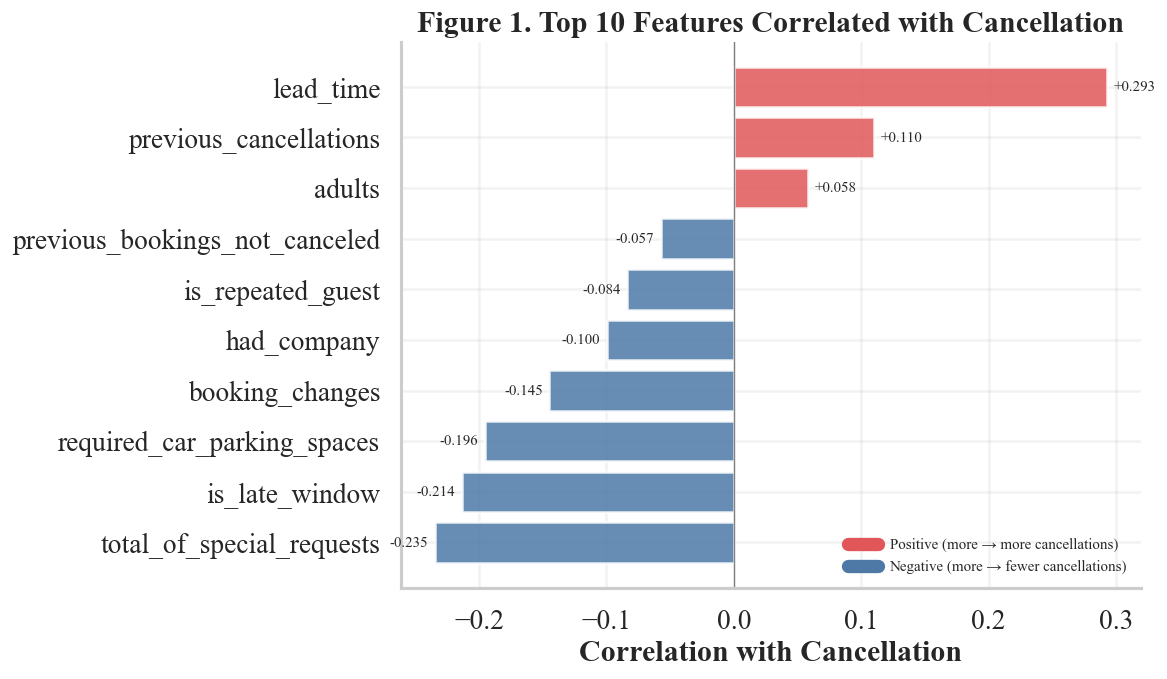

In [9]:
from src.eval.notebook_utils import plot_top_correlations_bar

plot_top_correlations_bar(df, TARGET_COL, FIG_DIR, fig_no=1, top_k=10)
plt.show()

In [10]:
leakage_in_data = [c for c in LEAKAGE_COLS if c in df_raw.columns]
leakage_df = pd.DataFrame({
    "column": leakage_in_data,
    "reason": [
        "Directly derived from outcome" if c == "reservation_status" else
        "Known only after check-in/outcome" if c == "reservation_status_date" else
        "Assigned at check-in, not booking time" if c == "assigned_room_type" else
        "Accumulated post-booking" if c == "booking_changes" else
        "Post-booking operational metric"
        for c in leakage_in_data
    ],
})
display(
    leakage_df.style
    .set_caption("Leakage Columns Excluded from Modeling")
    .hide(axis="index")
)

column,reason
reservation_status,Directly derived from outcome
reservation_status_date,Known only after check-in/outcome
assigned_room_type,"Assigned at check-in, not booking time"
booking_changes,Accumulated post-booking
days_in_waiting_list,Post-booking operational metric


**Key Takeaway — Leakage Prevention**: These columns are excluded because they contain information that would **not be available at booking time** (the moment we need to make our prediction). For example, `reservation_status` literally tells you whether the booking was cancelled — using it would be like looking at the answer sheet during an exam. Including these columns would make the model look unrealistically perfect, but it would be useless in practice.

## 1.8 Are Categorical Features Statistically Associated with Cancellations?

The correlations above only work for numerical features. For categorical features (hotel type, market segment, etc.), we use the **chi-squared test** — a standard statistical method that checks whether a feature is related to cancellations.

We tested every categorical booking-time feature and all are statistically significant (p < 0.05). **Cramer's V** measures the strength of the relationship: 0 = no relationship, 1 = perfect relationship.

In [11]:
from src.eval.notebook_utils import chi_squared_independence

# Test categorical booking-time features against cancellation status
# (exclude leakage columns — they won't be available at prediction time)
cat_cols = [
    c for c in df.select_dtypes(include="object").columns
    if c != TARGET_COL and c not in LEAKAGE_COLS
]
chi2_results = chi_squared_independence(df, cat_cols)

display(
    chi2_results.style
    .format({"p-value": "{:.2e}", "Cramér's V": "{:.4f}"})
    .set_caption("Chi-Squared Independence Tests: Categorical Features vs. Cancellation")
    .hide(axis="index")
)

Feature,Chi2 Statistic,p-value,Degrees of Freedom,Cramér's V,Significant?
deposit_type,27641.060000,0.00e+00,2,0.4815,Yes
country,15619.810000,0.00e+00,177,0.3620,Yes
market_segment,8499.730000,0.00e+00,7,0.2670,Yes
distribution_channel,3741.320000,0.00e+00,4,0.1772,Yes
hotel,2239.270000,0.00e+00,1,0.1371,Yes
customer_type,2224.650000,0.00e+00,3,0.1366,Yes
reserved_room_type,631.320000,4.31e-131,8,0.0728,Yes
arrival_date_month,582.080000,9.53e-118,11,0.0699,Yes
meal,305.030000,8.89e-65,4,0.0506,Yes


**Key Takeaway — Chi-Squared Results**: Every categorical feature is statistically associated with cancellation (all p-values far below 0.05). However, statistical significance alone doesn't tell us how *strong* the relationship is — with 119,000 bookings, even tiny differences become "significant". That's why **Cram&#233;r's V** matters more here:

- **Deposit type** has the strongest association (highest V) — consistent with the bar charts above showing near-100% cancellation for non-refundable deposits.
- **Market segment** and **customer type** show moderate associations — different booking channels genuinely have different cancellation patterns.
- Features with very low V (close to 0) are statistically significant but practically weak predictors on their own.

This confirms that our categorical features carry real predictive signal, and the gradient-boosted model can exploit these patterns through its one-hot encoding step.

## 1.9 Summary — What Did We Learn?

1. **About 1 in 3 bookings is cancelled** (37%). This is common enough that a prediction model can save real money, but not so extreme that we need special techniques to handle the imbalance.
2. **Lead time is the #1 predictor**: Guests who book far in advance are much more likely to cancel.
3. **Non-refundable deposits** show near-100% cancellation in the data, but this is a data-recording artefact, not a genuine signal.
4. **Cancellation rates change over time** (trending upward in late 2016), which is why we split data chronologically — the model must prove it works on "future" data.
5. **Missing data is manageable**: The biggest gap (`company`, 94% missing) simply means most guests don't have a corporate account. The pipeline handles all missing values automatically.
6. **5 columns are excluded** because they contain post-booking information that would "cheat" the model — we only use information available at the moment a booking is made.
7. **Chi-squared tests confirm** that all categorical features (hotel type, market segment, deposit type, customer type) are statistically associated with cancellation — this formal statistical evidence supports their inclusion in the model.

These findings guide the feature engineering and model building in **Notebook 02**.